# Gerador de ondas de weaving

## Triangular (adaptado da UFSC)


RESULTADOS

periodo                  : 0.8333
velocidadeX              : 2.5833
distanciaPeriodo         : 2.1528
distanciaUmMeioX         : 1.0764
distanciaUmQuartoX       : 0.5382
distanciaUmMeioY         : 6
distanciaOnda            : 24.0964
velocidadeHipotenusa     : 1734.9378
repeticoes               : 33
resto                    : -1.0417
tempoImpressao           : 27.5000

Comprimento trajetória: 795.1798 mm


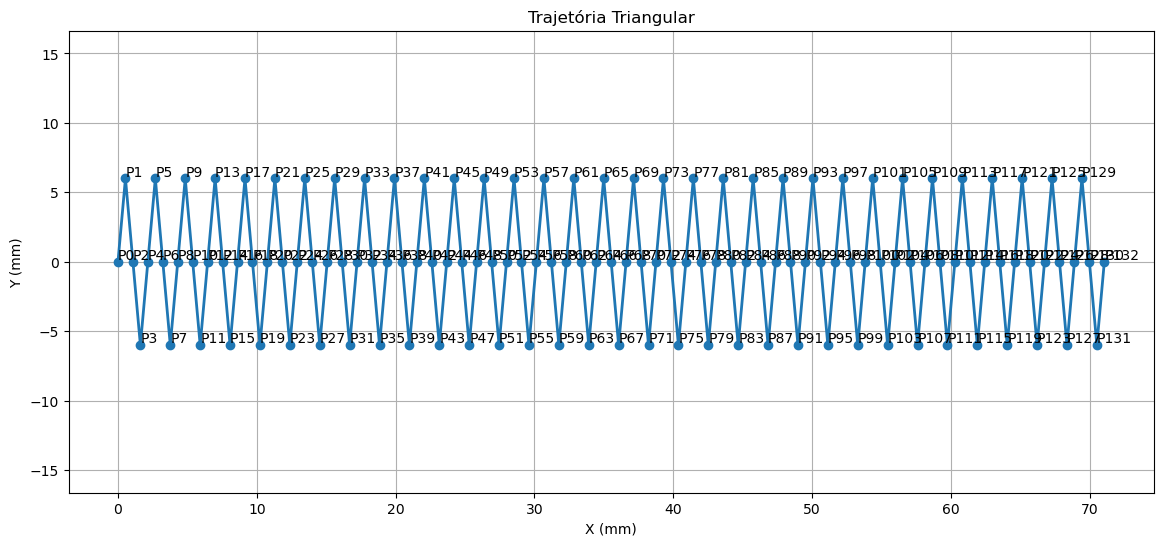


G CODE

G21 G64P0.25 G40 G49 G80 G90 G92.1 G94 G97 (preamble)
#<tube-cut>=1

(conversational trajectory {})
( Velocidade Soldagem = 15.5 cm/min )
( Amplitude = 6.0 mm )
( Frequencia = 1.2 Hz )
( Tempo de Parada 1 = 0.0 s )
( Tempo de Parada 2 = 0.0 s )
( Tempo de Disparo = 5.0 s )
( Distância total = 70.0 mm )

G0 X0 Y0
G01 G90 F1734.9377510446882
M200 P5.0

( Repeticoes = 33 )
( Resto = -1.0416666666666714 mm )

G1 G91 X0.54 Y6.0 F1734.9377510446882
G1 X0.54 Y-6.0 F1734.9377510446882
G1 X0.54 Y-6.0 F1734.9377510446882
G1 X0.54 Y6.0 F1734.9377510446882
G1 X0.54 Y6.0 F1734.9377510446882
G1 X0.54 Y-6.0 F1734.9377510446882
G1 X0.54 Y-6.0 F1734.9377510446882
G1 X0.54 Y6.0 F1734.9377510446882
G1 X0.54 Y6.0 F1734.9377510446882
G1 X0.54 Y-6.0 F1734.9377510446882
G1 X0.54 Y-6.0 F1734.9377510446882
G1 X0.54 Y6.0 F1734.9377510446882
G1 X0.54 Y6.0 F1734.9377510446882
G1 X0.54 Y-6.0 F1734.9377510446882
G1 X0.54 Y-6.0 F1734.9377510446882
G1 X0.54 Y6.0 F1734.9377510446882
G1 X0.54 Y6.0 F1734.937751

In [ ]:
import math
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, interactive
from IPython.display import clear_output

def calcular_trajetoria(frq, amp, vs, tp1, tp2, dist):
    periodo = 1 / frq
    velocidadeX = vs / 6
    compOnda = velocidadeX / frq
    distanciaUmMeioX = compOnda / 2
    distanciaUmQuartoX = compOnda / 4
    distanciaUmMeioY = amp
    distTotOnd = math.sqrt(
            (velocidadeX/frq)**2 + (amp*4)**2
        )
    velocidadeHipotenusa = frq*60*distTotOnd
    repeticoes = max(0,round(dist / compOnda))
    resto = dist - (repeticoes * compOnda)
    t_impressao = (repeticoes * distTotOnd) / velocidadeHipotenusa * 60
    return {
        "periodo": periodo,
        "velocidadeX": velocidadeX,
        "distanciaPeriodo": compOnda,
        "distanciaUmMeioX": distanciaUmMeioX,
        "distanciaUmQuartoX": distanciaUmQuartoX,
        "distanciaUmMeioY": distanciaUmMeioY,
        "distanciaOnda": distTotOnd,
        "velocidadeHipotenusa": velocidadeHipotenusa,
        "repeticoes": repeticoes,
        "resto": resto,
        "tempoImpressao": t_impressao
    }

def comprimento_trajetoria(x, y):
    comprimento = 0.0
    if len(x) != len(y):
        raise ValueError("x e y devem ter o mesmo comprimento")
    for i in range(1, len(x)):
        dx = x[i] - x[i-1]
        dy = y[i] - y[i-1]
        comprimento += math.hypot(dx, dy)
    return comprimento


def gerar_gcode(frq, amp, vs, tp1, tp2, dist, tdisparo=5):
    c = calcular_trajetoria(
        frq, amp, vs, tp1, tp2, dist
    )
    repeticoes = c["repeticoes"]
    resto = c["resto"]
    compOnda = c["distanciaPeriodo"]
    velocidade = c["velocidadeHipotenusa"]
    linhas = []
    pontos = [(0,0)]
    x = 0
    y = 0
    linhas.append("G21 G64P0.25 G40 G49 G80 G90 G92.1 G94 G97 (preamble)")
    linhas.append("#<tube-cut>=1")
    linhas.append("")
    linhas.append("(conversational trajectory {})")
    linhas.append(f"( Velocidade Soldagem = {vs:.1f} cm/min )")
    linhas.append(f"( Amplitude = {amp:.1f} mm )")
    linhas.append(f"( Frequencia = {frq:.1f} Hz )")
    linhas.append(f"( Tempo de Parada 1 = {tp1:.1f} s )")
    linhas.append(f"( Tempo de Parada 2 = {tp2:.1f} s )")
    linhas.append(f"( Tempo de Disparo = {tdisparo:.1f} s )")
    linhas.append(f"( Distância total = {dist:.1f} mm )")
    linhas.append("")
    linhas.append("G0 X0 Y0")
    linhas.append(f"G01 G90 F{velocidade}")
    linhas.append(f"M200 P{tdisparo:.1f}")
    linhas.append("")
    linhas.append(f"( Repeticoes = {repeticoes} )")
    linhas.append(f"( Resto = {resto} mm )")
    linhas.append("")
    # primeiro meio movimento
    linhas.append(
        f"G1 G91 X{compOnda/4:.2f} Y{amp:.1f} F{velocidade}"
    )
    x += compOnda/4
    y += amp
    pontos.append((x,y))
    for i in range(repeticoes):
        passox = compOnda/4
        passoy = amp
        linhas.append(
            f"G1 X{passox:.2f} Y{-passoy:.1f} F{velocidade}"
        )
        x += passox
        y -= passoy
        pontos.append((x,y))
        linhas.append(
            f"G1 X{passox:.2f} Y{-passoy:.1f} F{velocidade}"
        )
        x += passox
        y -= passoy
        pontos.append((x,y))
        linhas.append(
            f"G1 X{passox:.2f} Y{passoy:.1f} F{velocidade}"
        )
        x += passox
        y += passoy
        pontos.append((x,y))
        if i < repeticoes - 1:
            linhas.append(
                f"G1 X{passox:.2f} Y{passoy:.1f} F{velocidade}"
            )
            x += passox
            y += passoy
            pontos.append((x,y))
    if resto > 0:
        linhas.append(
            f"G1 X{resto:.2f} F{velocidade}"
        )
        x += resto
        pontos.append((x,y))
    linhas.append("")
    linhas.append("M200 P2.0")
    linhas.append("")
    linhas.append("G21 G64P0.25 G40 G49 G80 G90 G92.1 G94 G97 (postamble)")
    linhas.append("M2")
    return "\n".join(linhas), pontos, c

def atualizar(frq, amp, vs, tp1, tp2, dist):
    gcode, pontos, c = gerar_gcode(
        frq,
        amp,
        vs,
        tp1,
        tp2,
        dist
    )
    x = [p[0] for p in pontos]
    y = [p[1] for p in pontos]
    comprimento = comprimento_trajetoria(x, y)
    print("\nRESULTADOS\n")
    for k, v in c.items():
        if isinstance(v, float):
            print(f"{k:25s}: {v:.4f}")
        else:
            print(f"{k:25s}: {v}")
    print(f"\nComprimento trajetória: {comprimento:.4f} mm")
    plt.figure(figsize=(14,6))
    plt.plot(
        x,
        y,
        '-o',
        linewidth=2,
        markersize=6
    )
    for i, (xi, yi) in enumerate(zip(x, y)):
        plt.text(
            xi,
            yi + amp*0.03,
            f'P{i}'
        )
    plt.title("Trajetória Triangular")
    plt.xlabel("X (mm)")
    plt.ylabel("Y (mm)")
    plt.grid(True)
    plt.axis('equal')
    plt.show()
    print("\nG CODE\n")
    print(gcode)

# Criar sliders interativos para Voila
slider_frq = FloatSlider(
    value=1.2,
    min=0.5,
    max=5.0,
    step=0.1,
    description='Frequência (Hz):',
    style={'description_width': '150px'}
)

slider_amp = FloatSlider(
    value=6.0,
    min=1.0,
    max=20.0,
    step=0.5,
    description='Amplitude (mm):',
    style={'description_width': '150px'}
)

slider_vs = FloatSlider(
    value=15.5,
    min=5.0,
    max=50.0,
    step=0.5,
    description='Velocidade (cm/min):',
    style={'description_width': '150px'}
)

slider_tp1 = FloatSlider(
    value=0.0,
    min=0.0,
    max=10.0,
    step=0.1,
    description='Tempo Parada 1 (s):',
    style={'description_width': '150px'}
)

slider_tp2 = FloatSlider(
    value=0.0,
    min=0.0,
    max=10.0,
    step=0.1,
    description='Tempo Parada 2 (s):',
    style={'description_width': '150px'}
)

slider_dist = FloatSlider(
    value=70.0,
    min=10.0,
    max=250.0,
    step=1,
    description='Distância percorrida(mm):',
    style={'description_width': '150px'}
)

# Criar interface interativa
interactive_plot = interactive(
    atualizar,
    frq=slider_frq,
    amp=slider_amp,
    vs=slider_vs,
    tp1=slider_tp1,
    tp2=slider_tp2,
    dist=slider_dist
)

# Exibir a interface
interactive_plot
